--- ROSENBROCK RESULTS ---

Learning Rate: 0.01
GD         | Time: 0.1600s | f(x): nan | Opt x: [nan nan]


/tmp/ipykernel_3157/620586557.py:11: RuntimeWarning: overflow encountered in scalar power
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_3157/620586557.py:15: RuntimeWarning: overflow encountered in scalar power
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_3157/620586557.py:16: RuntimeWarning: overflow encountered in scalar power
  dy = 200 * (y - x**2)
/tmp/ipykernel_3157/620586557.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_3157/620586557.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_3157/620586557.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200 * (y - x**2)


Momentum   | Time: 0.1993s | f(x): nan | Opt x: [nan nan]
Adagrad    | Time: 0.2394s | f(x): 3.573624 | Opt x: [-0.88940474  0.79718374]
RMSprop    | Time: 0.2810s | f(x): 0.022451 | Opt x: [0.98014401 0.9755337 ]
Adam       | Time: 0.2166s | f(x): 0.000000 | Opt x: [0.99999897 0.99999794]


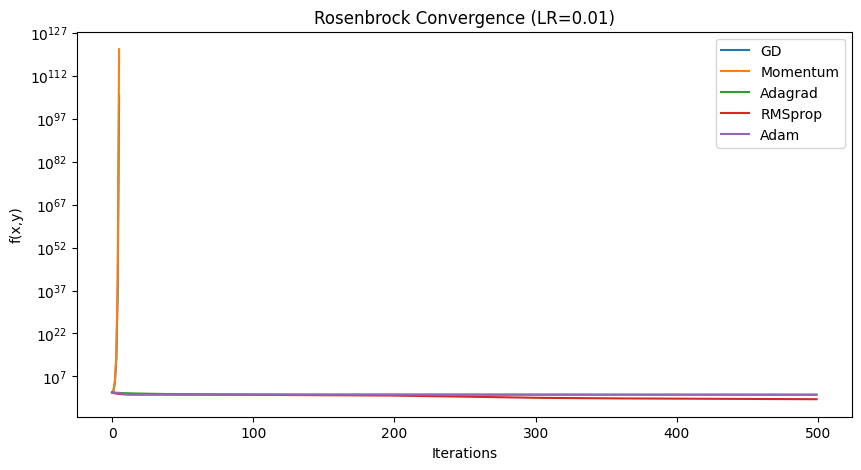


Learning Rate: 0.05
GD         | Time: 0.1686s | f(x): nan | Opt x: [nan nan]


/tmp/ipykernel_3157/620586557.py:15: RuntimeWarning: overflow encountered in scalar multiply
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_3157/620586557.py:44: RuntimeWarning: invalid value encountered in subtract
  return theta - self.lr * grad
/tmp/ipykernel_3157/620586557.py:55: RuntimeWarning: invalid value encountered in add
  self.v = self.momentum * self.v + self.lr * grad


Momentum   | Time: 0.1333s | f(x): nan | Opt x: [nan nan]
Adagrad    | Time: 0.1406s | f(x): 0.051219 | Opt x: [0.773802   0.59803894]
RMSprop    | Time: 0.2559s | f(x): 0.435625 | Opt x: [0.725    0.465625]
Adam       | Time: 0.1002s | f(x): 0.000000 | Opt x: [0.99999896 0.99999791]


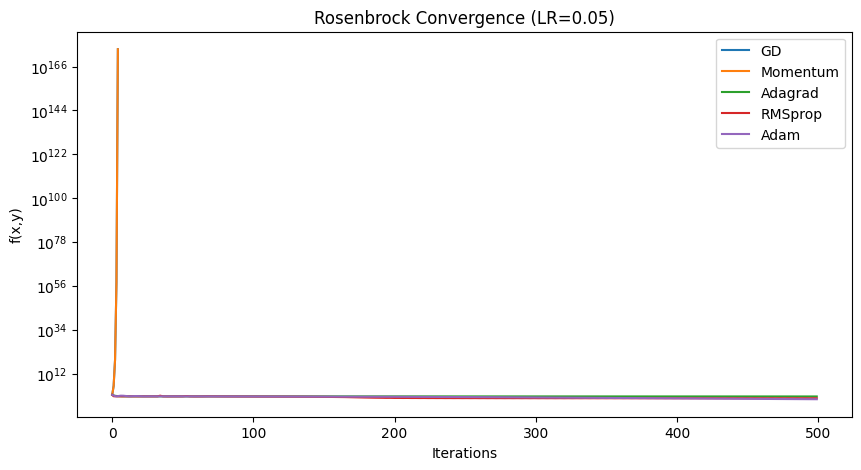


Learning Rate: 0.1
GD         | Time: 0.1277s | f(x): nan | Opt x: [nan nan]
Momentum   | Time: 0.1114s | f(x): nan | Opt x: [nan nan]
Adagrad    | Time: 0.1441s | f(x): 0.000627 | Opt x: [0.97497371 0.9504954 ]
RMSprop    | Time: 0.2652s | f(x): 1.052500 | Opt x: [0.3   0.015]
Adam       | Time: 0.0393s | f(x): 0.000000 | Opt x: [0.99999895 0.9999979 ]


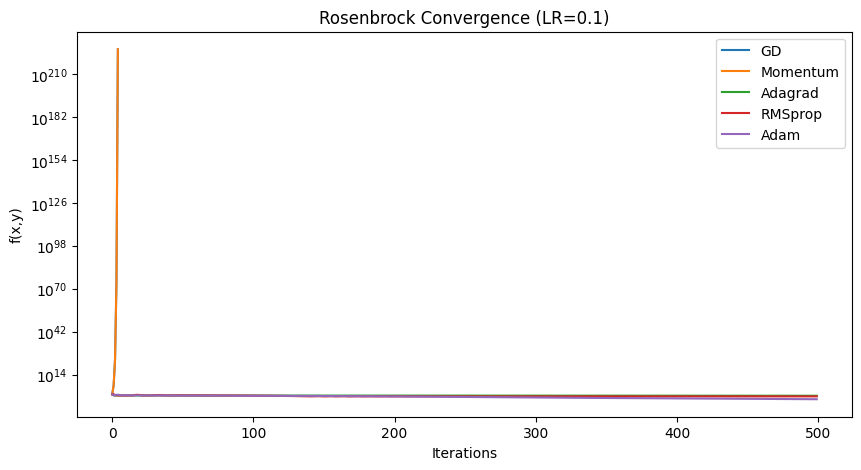


--- ACKLEY RESULTS ---

Learning Rate: 0.01
GD         | Time: 0.0019s | f(x): 6.559645 | Opt x: [1.97445199]
Momentum   | Time: 0.0105s | f(x): 3.574452 | Opt x: [-0.96847766]
Adagrad    | Time: 0.1779s | f(x): 6.559645 | Opt x: [1.974452]
RMSprop    | Time: 0.0034s | f(x): 6.559645 | Opt x: [1.97445199]
Adam       | Time: 0.0164s | f(x): 6.559645 | Opt x: [1.97445199]


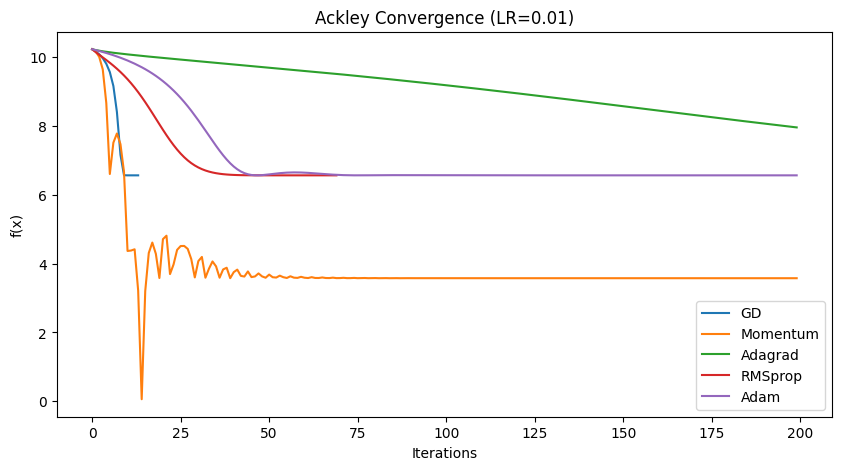


Learning Rate: 0.05
GD         | Time: 0.5434s | f(x): 4.264646 | Opt x: [-0.5030566]
Momentum   | Time: 0.6930s | f(x): 20.611078 | Opt x: [-76.11613896]
Adagrad    | Time: 0.0211s | f(x): 6.559645 | Opt x: [1.974452]
RMSprop    | Time: 0.8331s | f(x): 6.593224 | Opt x: [1.9481147]
Adam       | Time: 0.0221s | f(x): 6.559645 | Opt x: [1.97445199]


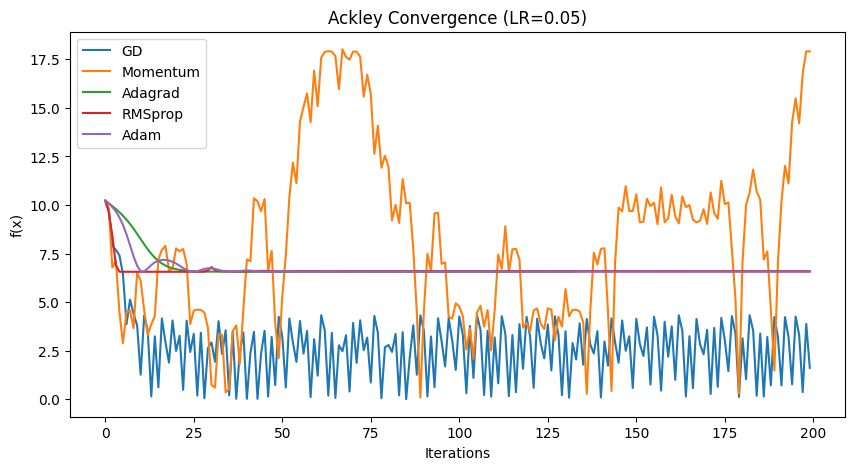


Learning Rate: 0.1
GD         | Time: 0.5641s | f(x): 3.580702 | Opt x: [0.95708817]
Momentum   | Time: 0.4216s | f(x): 20.999983 | Opt x: [-202.84104045]
Adagrad    | Time: 0.0018s | f(x): 6.559645 | Opt x: [1.97445199]
RMSprop    | Time: 0.3154s | f(x): 6.700612 | Opt x: [1.91848202]
Adam       | Time: 0.0197s | f(x): 6.559645 | Opt x: [1.97445199]


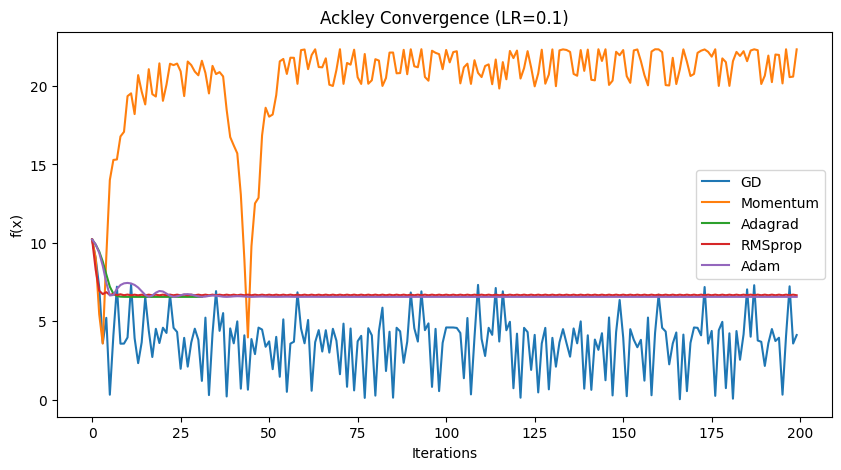

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time



def rosenbrock(theta):
    x, y = theta[0], theta[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(theta):
    x, y = theta[0], theta[1]
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

def ackley(theta):
    x = theta[0]
    if x == 0.0:
        return 0.0
    return -20 * np.exp(-0.2 * np.sqrt(x**2)) - np.exp(np.cos(2 * np.pi * x)) + 20 + np.e

def ackley_grad(theta):
    x = theta[0]
    if x == 0.0:
        return np.array([0.0])
    sign_x = 1.0 if x > 0 else -1.0
    term1 = 4 * sign_x * np.exp(-0.2 * np.abs(x))
    term2 = 2 * np.pi * np.sin(2 * np.pi * x) * np.exp(np.cos(2 * np.pi * x))
    return np.array([term1 + term2])



class Optimizer:
    def __init__(self, lr=0.01):
        self.lr = lr

class GradientDescent(Optimizer):
    def update(self, theta, grad):
        return theta - self.lr * grad

class SGDMomentum(Optimizer):
    def __init__(self, lr=0.01, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum
        self.v = None

    def update(self, theta, grad):
        if self.v is None:
            self.v = np.zeros_like(theta)
        self.v = self.momentum * self.v + self.lr * grad
        return theta - self.v

class Adagrad(Optimizer):
    def __init__(self, lr=0.01, epsilon=1e-8):
        super().__init__(lr)
        self.epsilon = epsilon
        self.G = None

    def update(self, theta, grad):
        if self.G is None:
            self.G = np.zeros_like(theta)
        self.G += grad**2
        return theta - (self.lr / np.sqrt(self.G + self.epsilon)) * grad

class RMSprop(Optimizer):
    def __init__(self, lr=0.01, beta=0.9, epsilon=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.epsilon = epsilon
        self.v = None

    def update(self, theta, grad):
        if self.v is None:
            self.v = np.zeros_like(theta)
        self.v = self.beta * self.v + (1 - self.beta) * grad**2
        return theta - (self.lr / np.sqrt(self.v + self.epsilon)) * grad

class Adam(Optimizer):
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None
        self.v = None
        self.t = 0

    def update(self, theta, grad):
        if self.m is None:
            self.m = np.zeros_like(theta)
            self.v = np.zeros_like(theta)
        self.t += 1

        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2

        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)

        return theta - (self.lr / (np.sqrt(v_hat) + self.epsilon)) * m_hat



def run_optimization(func, grad_func, start_theta, opt_class, lr, max_iter=10000, tol=1e-6):
    theta = np.array(start_theta, dtype=float)
    optimizer = opt_class(lr=lr)

    history_theta = [theta.copy()]
    history_f = [func(theta)]

    start_time = time.time()

    for _ in range(max_iter):
        grad = grad_func(theta)

        if np.linalg.norm(grad) < tol:
            break

        theta = optimizer.update(theta, grad)

        history_theta.append(theta.copy())
        history_f.append(func(theta))

    end_time = time.time()

    return theta, func(theta), history_f, (end_time - start_time)

# Settings
learning_rates = [0.01, 0.05, 0.1]
optimizers = {
    "GD": GradientDescent,
    "Momentum": SGDMomentum,
    "Adagrad": Adagrad,
    "RMSprop": RMSprop,
    "Adam": Adam
}

# Run Rosenbrock
print("--- ROSENBROCK RESULTS ---")
start_pos_rosen = [-1.2, 1.0] 
for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    plt.figure(figsize=(10, 5))
    for name, opt in optimizers.items():
        opt_theta, opt_f, hist_f, t = run_optimization(rosenbrock, rosenbrock_grad, start_pos_rosen, opt, lr)
        print(f"{name:10} | Time: {t:.4f}s | f(x): {opt_f:.6f} | Opt x: {opt_theta}")
        plt.plot(hist_f[:500], label=f"{name}") # Plot first 500 steps for clarity

    plt.title(f"Rosenbrock Convergence (LR={lr})")
    plt.xlabel("Iterations")
    plt.ylabel("f(x,y)")
    plt.yscale('log')
    plt.legend()
    plt.show()

# Run Ackley
print("\n--- ACKLEY RESULTS ---")
start_pos_ackley = [2.5]
for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    plt.figure(figsize=(10, 5))
    for name, opt in optimizers.items():
        opt_theta, opt_f, hist_f, t = run_optimization(ackley, ackley_grad, start_pos_ackley, opt, lr)
        print(f"{name:10} | Time: {t:.4f}s | f(x): {opt_f:.6f} | Opt x: {opt_theta}")
        plt.plot(hist_f[:200], label=f"{name}")

    plt.title(f"Ackley Convergence (LR={lr})")
    plt.xlabel("Iterations")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

np.random.seed(42)

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame


X_raw = df[["MedInc", "HouseAge"]].values
y_raw = df["MedHouseVal"].values

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)

X shape: (20640, 2)
y shape: (20640,)


In [ ]:

n_samples = X_raw.shape[0]
indices = np.random.permutation(n_samples)

split_point = int(0.8 * n_samples)
train_idx, test_idx = indices[:split_point], indices[split_point:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train, y_test = y_raw[train_idx], y_raw[test_idx]

feature_mean = X_train_raw.mean(axis=0)
feature_std = X_train_raw.std(axis=0)

X_train = (X_train_raw - feature_mean) / feature_std
X_test = (X_test_raw - feature_mean) / feature_std

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 16512  Test size: 4128


In [ ]:


def init_params(input_dim=2, seed=42):
    rng = np.random.default_rng(seed)
    params = {
        "W1": rng.standard_normal((input_dim, 5)) * 0.1, "b1": np.zeros(5),
        "W2": rng.standard_normal((5, 3)) * 0.1,         "b2": np.zeros(3),
        "W3": rng.standard_normal((3, 1)) * 0.1,         "b3": np.zeros(1),
    }
    return params

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def forward(params, X):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]   
    y_pred = Z3.flatten()
    cache = (X, Z1, A1, Z2, A2)
    return y_pred, cache

def backward(params, cache, y_true, y_pred):
    X, Z1, A1, Z2, A2 = cache
    m = X.shape[0]

   
    dZ3 = ((y_pred - y_true) * (2.0 / m)).reshape(-1, 1)

    grads = {}
    grads["W3"] = A2.T @ dZ3
    grads["b3"] = dZ3.sum(axis=0)

    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * relu_deriv(Z2)
    grads["W2"] = A1.T @ dZ2
    grads["b2"] = dZ2.sum(axis=0)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_deriv(Z1)
    grads["W1"] = X.T @ dZ1
    grads["b1"] = dZ1.sum(axis=0)

    return grads

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [ ]:


def init_optimizer_state(optimizer_type, params):
    state = {}
    if optimizer_type in ("momentum", "adam"):
        state["v"] = {k: np.zeros_like(v) for k, v in params.items()}
    if optimizer_type == "adam":
        state["s"] = {k: np.zeros_like(v) for k, v in params.items()}
        state["t"] = 0
    return state

def update_params(params, grads, optimizer_type, state, lr,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    if optimizer_type == "gd":
        for k in params:
            params[k] = params[k] - lr * grads[k]

    elif optimizer_type == "momentum":
        for k in params:
            state["v"][k] = beta1 * state["v"][k] + (1 - beta1) * grads[k]
            params[k] = params[k] - lr * state["v"][k]

    elif optimizer_type == "adam":
        state["t"] += 1
        for k in params:
            state["v"][k] = beta1 * state["v"][k] + (1 - beta1) * grads[k]
            state["s"][k] = beta2 * state["s"][k] + (1 - beta2) * (grads[k] ** 2)
            v_hat = state["v"][k] / (1 - beta1 ** state["t"])
            s_hat = state["s"][k] / (1 - beta2 ** state["t"])
            params[k] = params[k] - lr * v_hat / (np.sqrt(s_hat) + eps)

    else:
        raise ValueError("Unknown optimizer_type: " + optimizer_type)

    return params, state

In [ ]:


def train(X_train, y_train, X_test, y_test,
          optimizer_type="gd", lr=0.01, epochs=1000, seed=42):

    params = init_params(input_dim=X_train.shape[1], seed=seed)
    state = init_optimizer_state(optimizer_type, params)

    train_losses = []
    for epoch in range(epochs):
        y_pred, cache = forward(params, X_train)
        loss = mse(y_train, y_pred)
        train_losses.append(loss)

        grads = backward(params, cache, y_train, y_pred)
        params, state = update_params(params, grads, optimizer_type, state, lr)

    y_test_pred, _ = forward(params, X_test)
    test_loss = mse(y_test, y_test_pred)

    return params, train_losses, test_loss

lr=0.01   final train loss=0.6377  test loss=0.6655
lr=0.001  final train loss=1.3981  test loss=1.4180


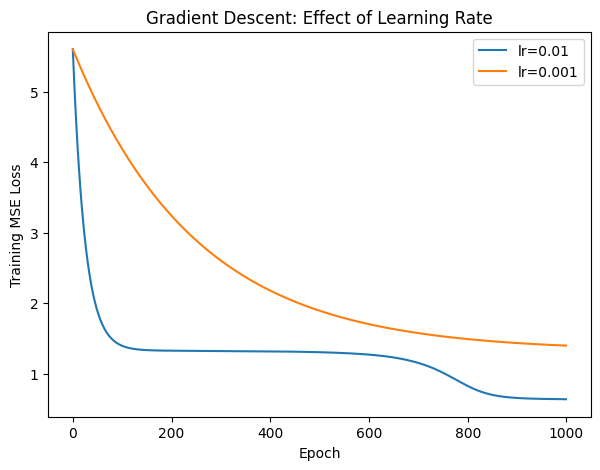

In [8]:
learning_rates = [0.01, 0.001]
epochs = 1000
lr_results = {}

for lr in learning_rates:
    params, train_losses, test_loss = train(
        X_train, y_train, X_test, y_test,
        optimizer_type="gd", lr=lr, epochs=epochs
    )
    lr_results[lr] = train_losses
    print(f"lr={lr:<6} final train loss={train_losses[-1]:.4f}  test loss={test_loss:.4f}")

plt.figure(figsize=(7, 5))
for lr, losses in lr_results.items():
    plt.plot(losses, label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Gradient Descent: Effect of Learning Rate")
plt.legend()
plt.show()

optimizer=gd        final train loss=0.6377  test loss=0.6655
optimizer=momentum  final train loss=0.7003  test loss=0.7215
optimizer=adam      final train loss=0.6396  test loss=0.6652


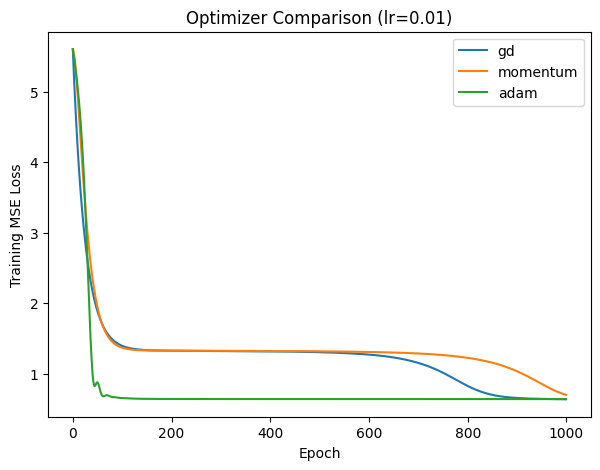

In [ ]:

optimizers = ["gd", "momentum", "adam"]
lr = 0.01
epochs = 1000
opt_results = {}
opt_final_params = {}

for opt in optimizers:
    params, train_losses, test_loss = train(
        X_train, y_train, X_test, y_test,
        optimizer_type=opt, lr=lr, epochs=epochs
    )
    opt_results[opt] = train_losses
    opt_final_params[opt] = params
    print(f"optimizer={opt:<9} final train loss={train_losses[-1]:.4f}  test loss={test_loss:.4f}")

plt.figure(figsize=(7, 5))
for opt, losses in opt_results.items():
    plt.plot(losses, label=opt)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title(f"Optimizer Comparison (lr={lr})")
plt.legend()
plt.show()

Test MSE (Adam model): 0.6652


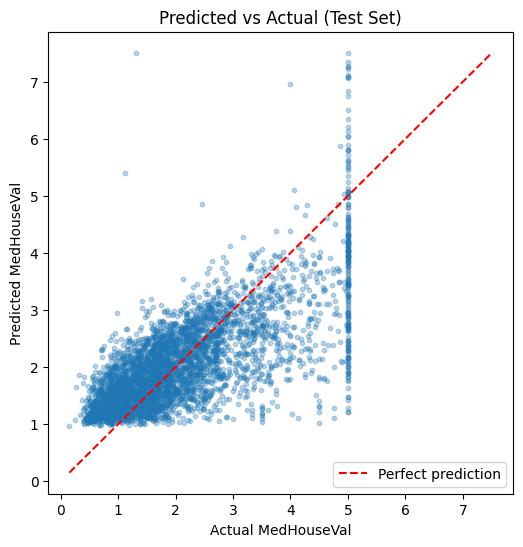

In [10]:
best_params = opt_final_params["adam"]
y_test_pred, _ = forward(best_params, X_test)

test_mse = mse(y_test, y_test_pred)
print(f"Test MSE (Adam model): {test_mse:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs Actual (Test Set)")
plt.legend()
plt.show()